In [1]:
import os
import sys

# import warnings
# warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from humanize import naturalsize

In [2]:
# Get the current working directory
cwd = os.getcwd()

# Go up two levels
parent_dir = os.path.dirname(cwd)
grandparent_dir = os.path.dirname(parent_dir)

# Change the working directory
os.chdir(grandparent_dir)

print(f"Set working  directory to:{os.getcwd()}")

Set working  directory to:c:\Users\sega9\Documents\GA Tech\2024.Fall\ISYE 7406\Project\apartments


In [3]:
# Load performance metrics
base_metrics_path = 'models/base/model_performance_metrics.csv'
tuned_metrics_path = 'models/tuned/model_performance_metrics.csv'


base_metrics = pd.read_csv(base_metrics_path, index_col=0).drop(columns='Time (min)')
tuned_metrics = pd.read_csv(tuned_metrics_path, index_col=0).drop(columns='Time (min)')

In [4]:
print("\n--Default Model Performance--")
print(base_metrics)

print("\n--Tuned Model Performance--")
print(tuned_metrics)



--Default Model Performance--
                        R-squared            MSE       MedAE         MAE
Ridge Regression         0.776611  228444.096575  149.721763  232.915200
Lasso Regression        -0.000054  778210.998986  349.127266  492.695975
Decision Tree            0.762482  321601.167052   85.000000  202.346464
Random Forest            0.877963  153238.815107   75.473335  151.909440
Hist Gradient Boosting   0.827621  188529.835662  129.856948  203.894922
XGBoost                  0.845013  156636.543487  118.951721  190.885812

--Tuned Model Performance--
                        R-squared            MSE       MedAE         MAE
Ridge Regression         0.776591  228402.683893  149.690255  232.940091
Lasso Regression         0.775474  229964.191182  149.751861  233.435594
Decision Tree            0.792617  221243.267906  108.055876  204.737775
Random Forest            0.879334  151458.708951   74.937770  151.000304
Hist Gradient Boosting   0.878863  150896.095075   95.814906  16

In [5]:
# Comparing performance between default and tuned models
comparison = pd.concat([base_metrics, tuned_metrics], axis=1)
comparison.columns = ['R-squared (Default)', 'MSE (Default)', 'MedAE (Default)', 'MAE (Default)', 'R-squared (Tuned)', 'MSE (Tuned)', 'MedAE (Tuned)', 'MAE (Tuned)']

print("\n--Comparison of Default and Tuned Model Performance--")
print(comparison)


--Comparison of Default and Tuned Model Performance--
                        R-squared (Default)  MSE (Default)  MedAE (Default)  \
Ridge Regression                   0.776611  228444.096575       149.721763   
Lasso Regression                  -0.000054  778210.998986       349.127266   
Decision Tree                      0.762482  321601.167052        85.000000   
Random Forest                      0.877963  153238.815107        75.473335   
Hist Gradient Boosting             0.827621  188529.835662       129.856948   
XGBoost                            0.845013  156636.543487       118.951721   

                        MAE (Default)  R-squared (Tuned)    MSE (Tuned)  \
Ridge Regression           232.915200           0.776591  228402.683893   
Lasso Regression           492.695975           0.775474  229964.191182   
Decision Tree              202.346464           0.792617  221243.267906   
Random Forest              151.909440           0.879334  151458.708951   
Hist Gradient Bo

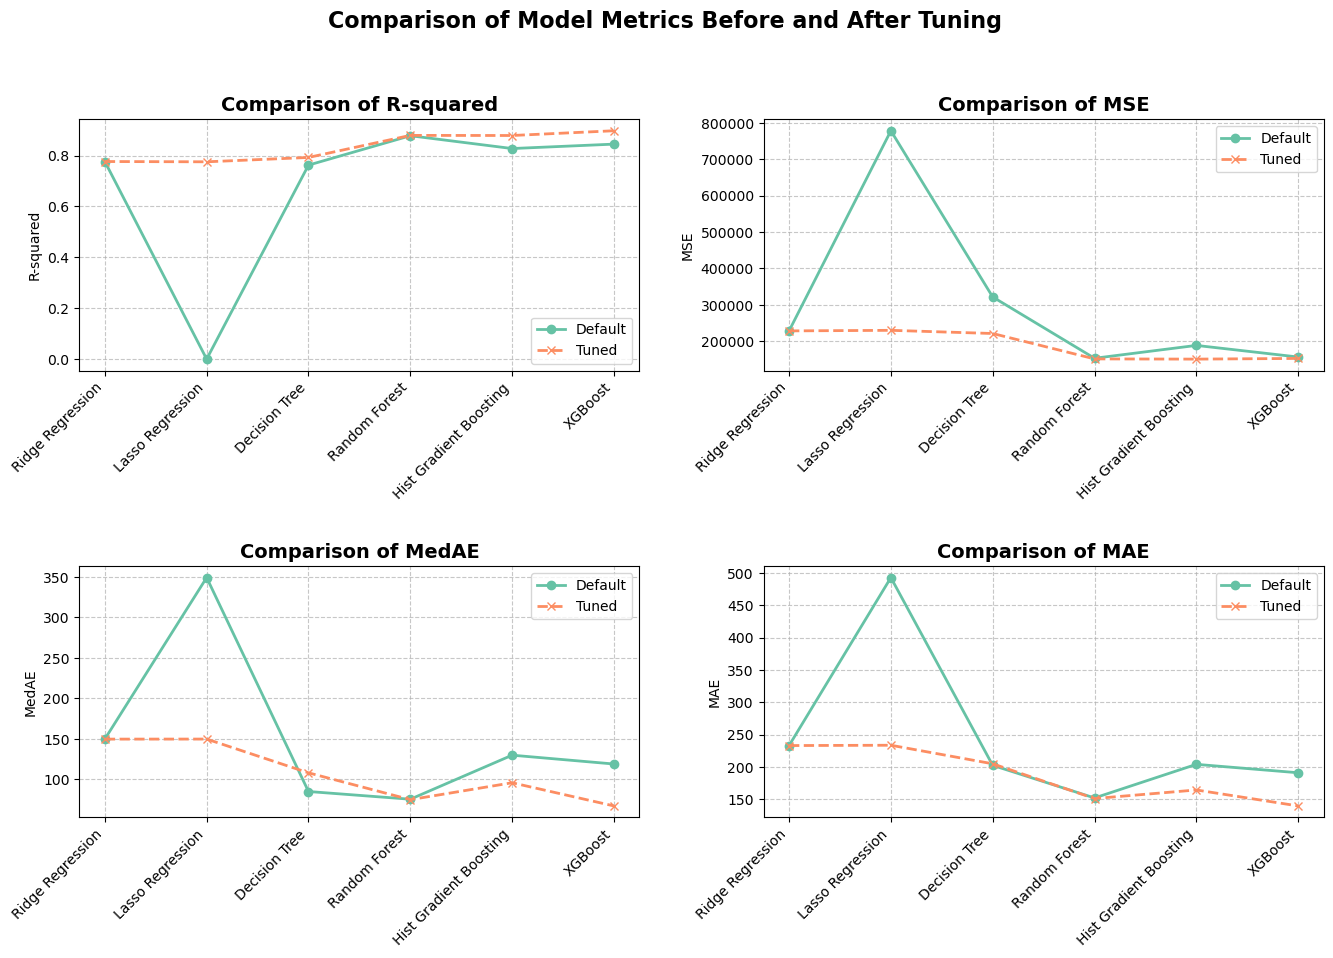

In [6]:
# Plot comparison of R-squared, MSE, MedAE, and MAE between default and tuned models
metrics = ['R-squared', 'MSE', 'MedAE', 'MAE']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))  # 2x2 grid of subplots

# Use a color palette for consistency
colors = sns.color_palette("Set2", 2)  # Using Set2 palette for a softer color scheme

for i, metric in enumerate(metrics):
    row = i // 2
    col = i % 2
    ax = axs[row, col]
    
    ax.plot(base_metrics[metric], label='Default', marker='o', color=colors[0], linestyle='-', linewidth=2)
    ax.plot(tuned_metrics[metric], label='Tuned', marker='x', color=colors[1], linestyle='--', linewidth=2)
    
    ax.set_title(f'Comparison of {metric}', fontsize=14, fontweight='bold')
    ax.set_xticks(np.arange(len(base_metrics)))
    ax.set_xticklabels(base_metrics.index, rotation=45, ha='right')
    ax.set_ylabel(metric)
    
    # Add grid for better readability
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Add legend
    ax.legend(loc='best', fontsize=10)

# Add a main title to all subplots
plt.suptitle(f"Comparison of Model Metrics Before and After Tuning", fontsize=16, fontweight='bold')


# Adjust layout and spacing
plt.tight_layout(pad=3.0)
plt.show()


In [7]:
# Load feature importance 
base_importance = pd.read_csv('models/base/feature_importance_results.csv').rename(columns={'Unnamed: 0': 'Feature'})
tuned_importance = pd.read_csv('models/tuned/feature_importance_results.csv').rename(columns={'Unnamed: 0': 'Feature'})

# Plotting feature importance comparison for different models
models = ['Ridge_Regression', 'Lasso_Regression', 'Decision_Tree', 'Random_Forest', 'XGBoost', 'Hist_Gradient_Boosting']

base_importance['Hist_Gradient_Boosting'] = base_importance['Hist_Gradient_Boosting'].abs()
tuned_importance['Hist_Gradient_Boosting'] = tuned_importance['Hist_Gradient_Boosting'].abs()


In [8]:
# Display the updated base_importance dataframe
print("\n--Base Feature Importance--")
print(base_importance.head())

# Display the updated tuned_importance dataframe
print("\n--Tuned Feature Importance--")
print(tuned_importance.head())


--Base Feature Importance--
       Feature  Ridge_Regression  Lasso_Regression  Decision_Tree  \
0      zipcode          0.741836               0.0       0.357963   
1   POPULATION          0.004844               0.0       0.015651   
2     POP_SQMI          0.046703               0.0       0.056245   
3  perc_sub25k          0.035702               0.0       0.048224   
4  perc_25_50k          0.134263               0.0       0.017031   

   Random_Forest   XGBoost  Hist_Gradient_Boosting  
0       0.354165  0.060224                0.008791  
1       0.016836  0.001224                0.003127  
2       0.058886  0.012554                0.109699  
3       0.052187  0.012280                0.007331  
4       0.021152  0.011837                0.064921  

--Tuned Feature Importance--
       Feature  Ridge_Regression  Lasso_Regression  Decision_Tree  \
0      zipcode          0.897603          0.077963       0.386780   
1   POPULATION          0.004820          0.004933       0.014791   
2

In [9]:
# Limit the number of features to plot (e.g., top 20)
n_top_features = 30

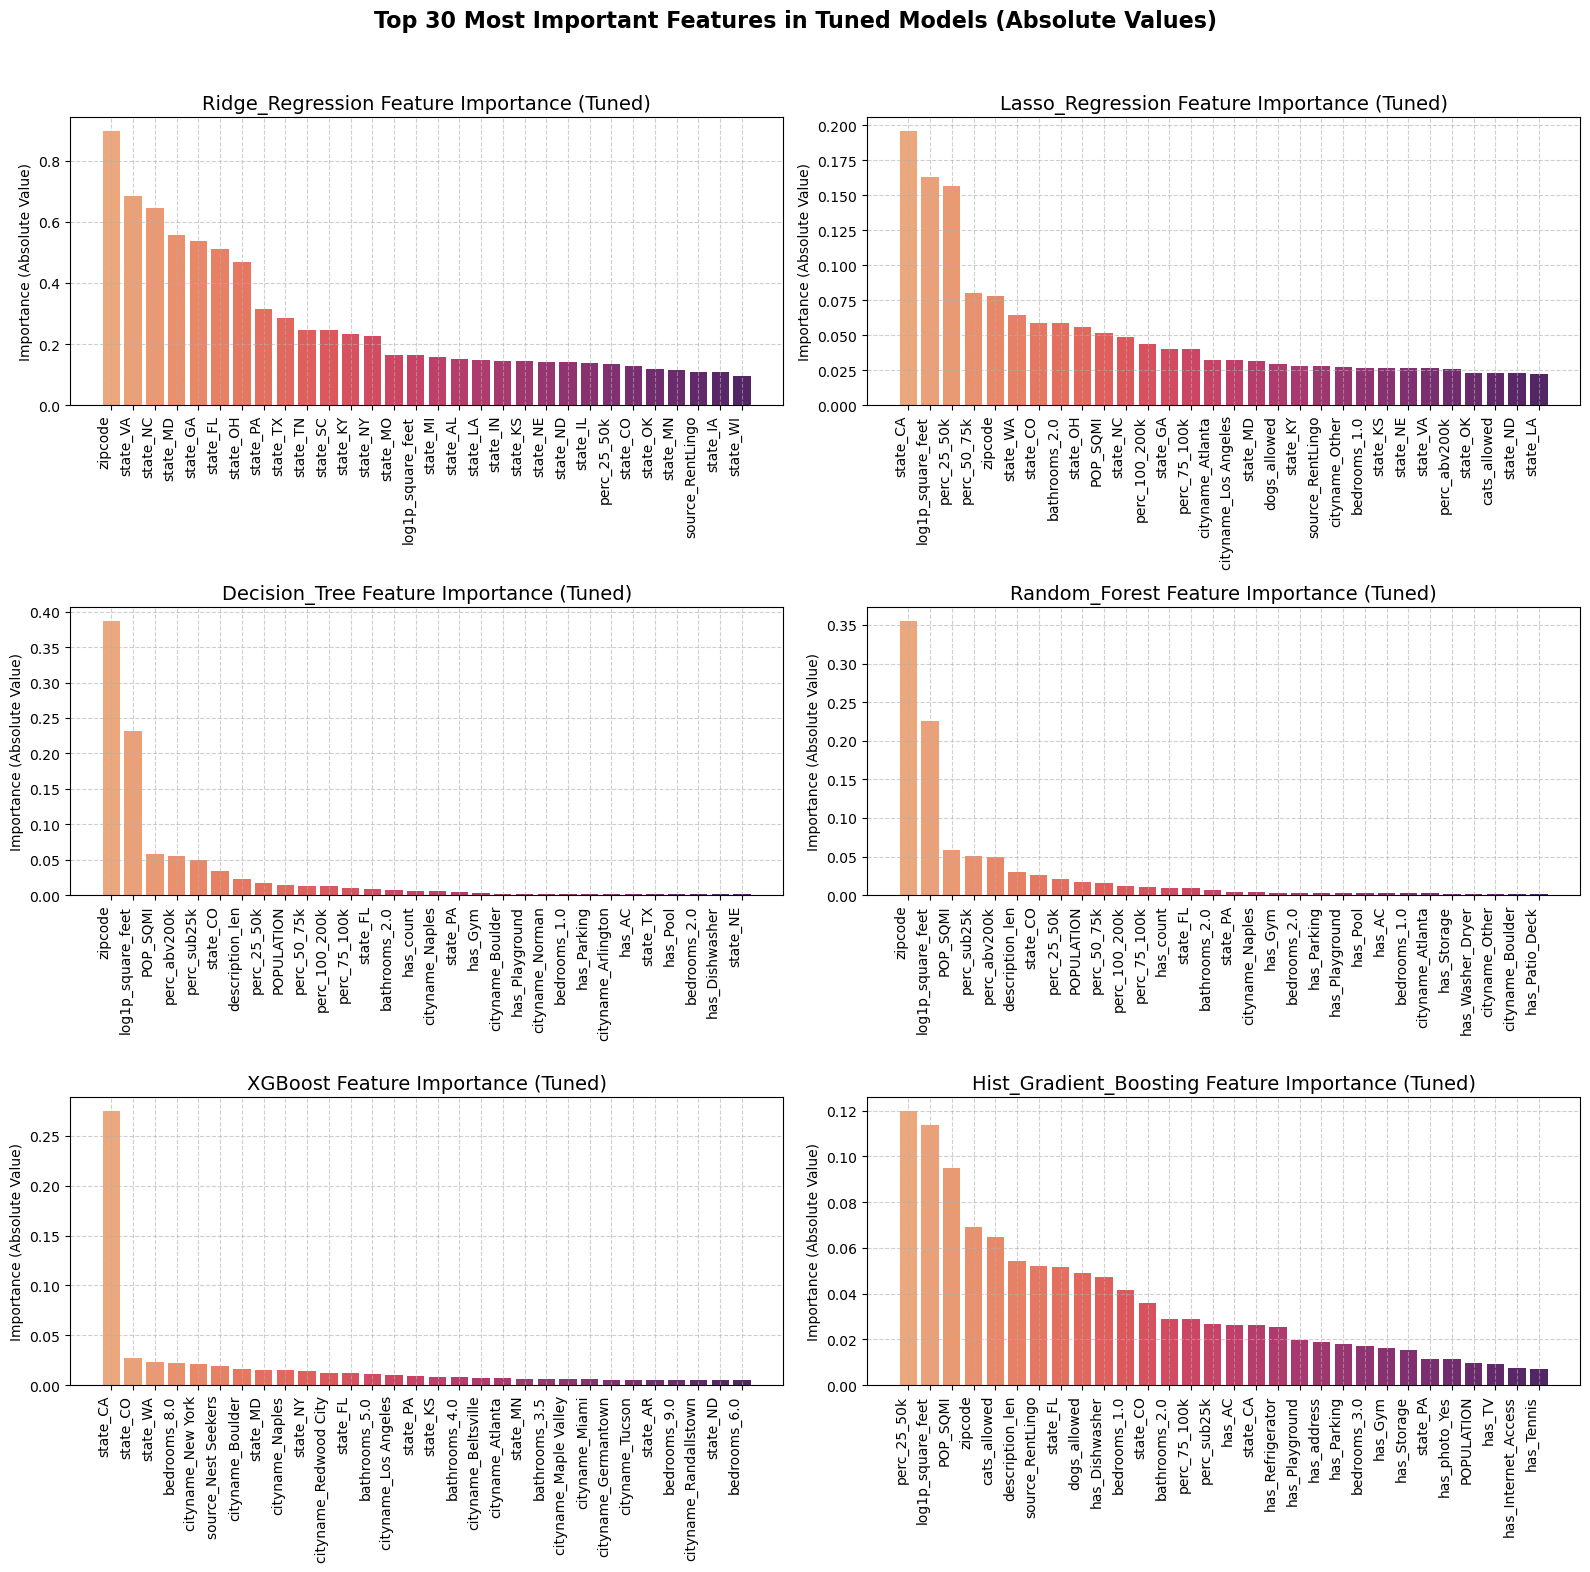

In [10]:
# Set the number of models (rows and columns for subplots)
fig, axs = plt.subplots(3, 2, figsize=(16, 16))  # 3 rows, 2 columns grid for 5 models
fig.suptitle(f'Top {n_top_features} Most Important Features in Tuned Models (Absolute Values)', fontsize=16, fontweight='bold')

# Generate sequential color palettes for the bars
for i, model in enumerate(models):
    row = i // 2
    col = i % 2
    ax = axs[row, col]
    
    # Sorting the features by their absolute importance in the tuned models
    tuned_importance[model] = tuned_importance[model].abs()  # Take the absolute values
    sorted_features = tuned_importance[['Feature', model]].sort_values(by=model, ascending=False).head(n_top_features)
    
    # Generate a sequential color palette for each model
    colors = sns.color_palette("flare", len(sorted_features))
    
    # Plotting the top features with a sequential color palette
    ax.bar(sorted_features['Feature'], sorted_features[model], color=colors)
    
    # Set title and labels for each subplot
    ax.set_title(f'{model} Feature Importance (Tuned)', fontsize=14)
    ax.set_xticks(np.arange(len(sorted_features)))
    ax.set_xticklabels(sorted_features['Feature'], rotation=90, ha='right')
    ax.set_ylabel('Importance (Absolute Value)')
    
    # Add a grid for readability
    ax.grid(True, linestyle='--', alpha=0.6)

# Adjust layout and spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])  # rect used to avoid overlap with suptitle
plt.show()

In [51]:
def categorize_feature(feature):
    if feature.startswith('cityname_'):
        return 'City'
    elif feature.startswith('state_'):
        return 'State'
    elif feature.startswith('source_'):
        return 'Source'
    elif feature.startswith('zipcode'):
        return 'Zipcode'
    elif feature.startswith('perc_'):
        return 'Income Percentile'
    elif feature.startswith('has_'):
        return 'Amenities'
    elif 'bedrooms_' in feature:
        return 'Bedrooms'
    elif 'bathrooms_' in feature:
        return 'Bathrooms'
    elif 'square_feet' in feature:
        return 'Square Footage'
    elif 'POPULATION' in feature or 'POP_SQMI' in feature:
        return 'Population'
    else:
        return 'Other'

In [52]:
tuned_importance['Feature_Category'] = tuned_importance['Feature'].apply(categorize_feature)

category_avg_importance = tuned_importance.groupby('Feature_Category')[models].mean().reset_index()
category_avg_importance['All Models Avg'] = category_avg_importance[models].mean(axis=1)

category_avg_importance

,Feature_Category,Ridge_Regression,Lasso_Regression,Decision_Tree,Random_Forest,XGBoost,Hist_Gradient_Boosting,All Models Avg
0,Amenities,0.006878,0.006750,0.001038,0.001561,0.000430,0.008456,0.004186
1,Bathrooms,0.010314,0.010272,0.000509,0.000633,0.003490,0.002320,0.004590
2,Bedrooms,0.005283,0.005134,0.000470,0.000778,0.004119,0.007436,0.003870
3,City,0.004439,0.004480,0.000080,0.000095,0.001170,0.000326,0.001765
4,Income Percentile,0.062323,0.057708,0.026195,0.026769,0.001712,0.031183,0.034315
5,Other,0.024901,0.022438,0.007888,0.011064,0.000193,0.055947,0.020405
6,Population,0.025367,0.028050,0.036432,0.037526,0.001327,0.052215,0.030153
7,Source,0.013322,0.002632,0.000072,0.000128,0.001396,0.002639,0.003365
8,Square Footage,0.162885,0.162677,0.232290,0.225589,0.001836,0.113734,0.149835
9,State,0.177373,0.022030,0.001266,0.001179,0.010464,0.003800,0.036019


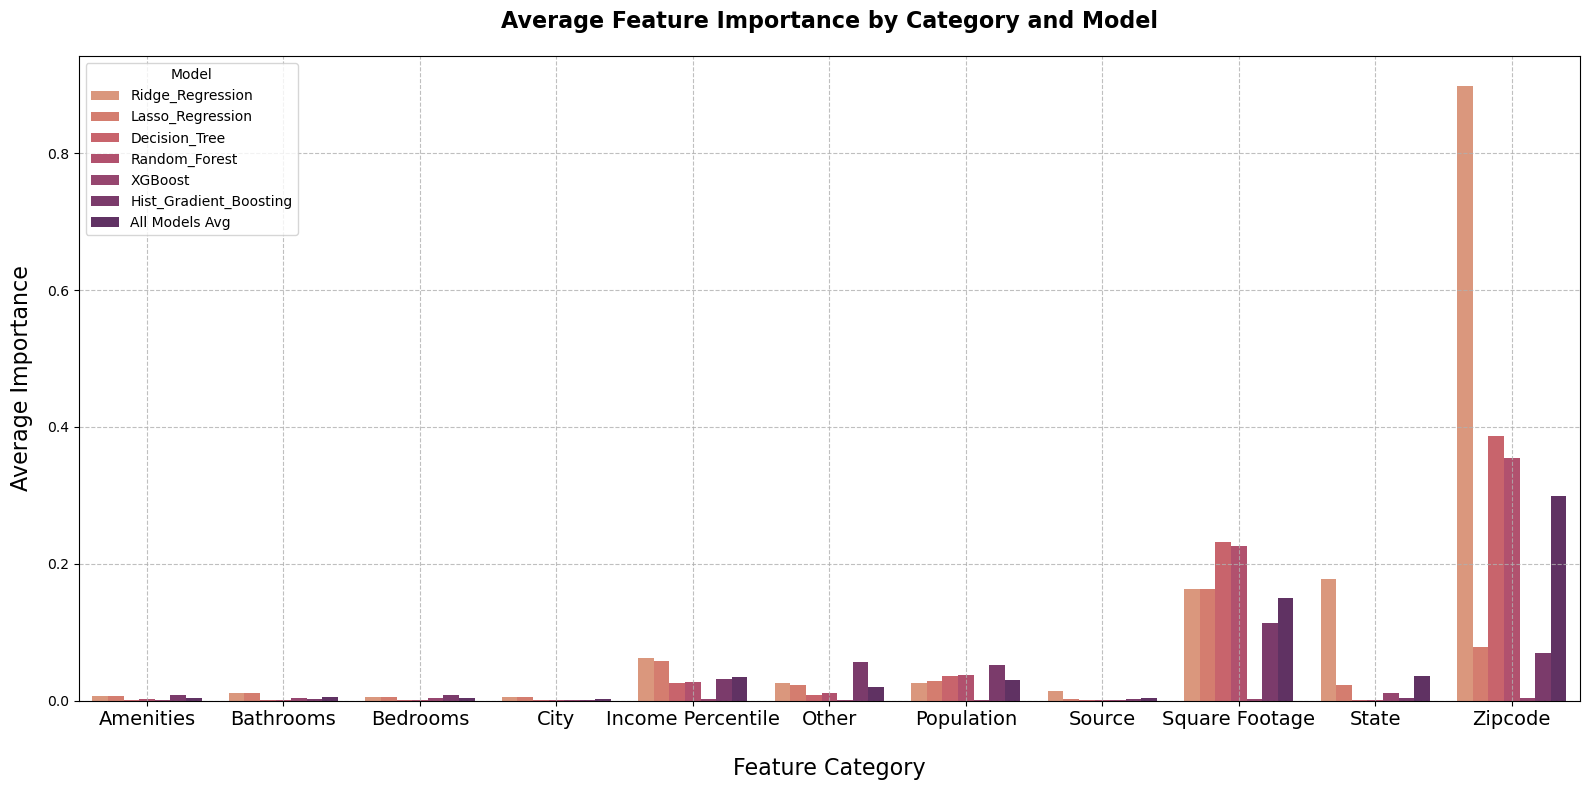

In [53]:
# Melt the DataFrame to long format
melted_importance = category_avg_importance.melt(id_vars='Feature_Category', 
                                                  var_name='Model', 
                                                  value_name='Importance')

# Set figure size
plt.figure(figsize=(16, 8))

# Create the bar plot with flare color palette
ax = sns.barplot(data=melted_importance, x='Feature_Category', y='Importance', hue='Model', palette="flare")

# Customize the plot
plt.title('Average Feature Importance by Category and Model', fontsize=16, fontweight='bold', pad=20)

# Customize axes labels
plt.xlabel('Feature Category', fontsize=16, labelpad=20)
plt.ylabel('Average Importance', fontsize=16, labelpad=10)

# Rotate x-axis labels
plt.xticks(fontsize=14)
plt.yticks(fontsize=10)

# Add grid
plt.grid(True, linestyle='--', alpha=0.8)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()


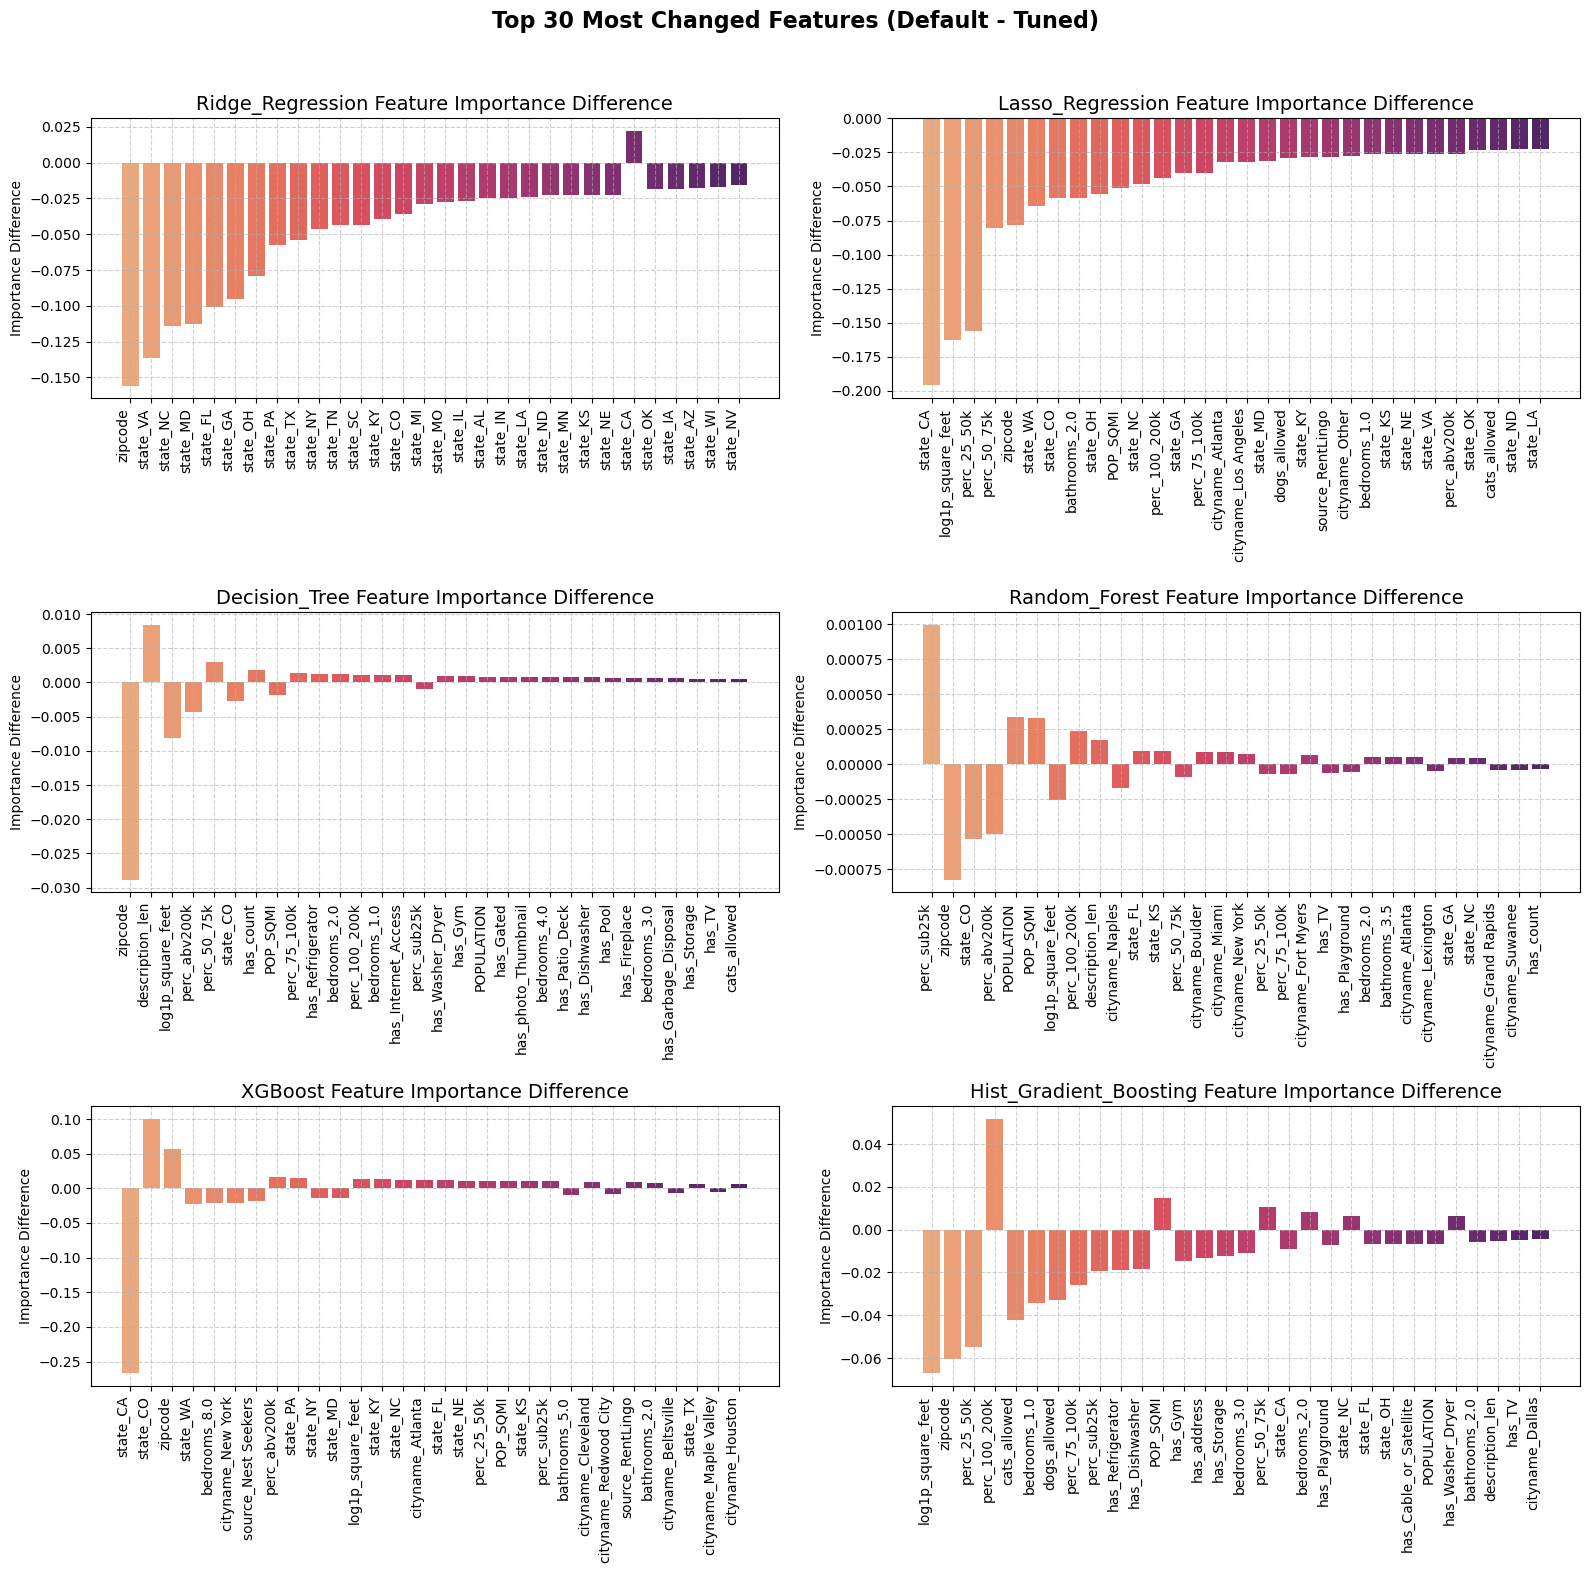

In [14]:
# Calculate the differences in feature importance between default and tuned models
feature_comparison = base_importance.set_index('Feature').subtract(tuned_importance.set_index('Feature'))

# Set the number of models (rows and columns for subplots)
fig, axs = plt.subplots(3, 2, figsize=(16, 16))  # 3 rows, 2 columns grid for 5 models
fig.suptitle(f'Top {n_top_features} Most Changed Features (Default - Tuned)', fontsize=16, fontweight='bold')

# Generate sequential color palettes for the bars
for i, model in enumerate(models):
    row = i // 2
    col = i % 2
    ax = axs[row, col]
    
    # Sorting the features by the absolute difference in importance
    diff_sorted = feature_comparison[model].abs().sort_values(ascending=False).head(n_top_features)
    
    # Generate a sequential color palette for each model
    colors = sns.color_palette("flare", len(diff_sorted))
    
    # Plotting the differences with a sequential color palette
    ax.bar(diff_sorted.index, feature_comparison.loc[diff_sorted.index, model], color=colors)
    
    # Set title and labels for each subplot
    ax.set_title(f'{model} Feature Importance Difference', fontsize=14)
    ax.set_xticks(np.arange(len(diff_sorted)))
    ax.set_xticklabels(diff_sorted.index, rotation=90, ha='right')
    ax.set_ylabel('Importance Difference')
    
    # Add a grid for readability
    ax.grid(True, linestyle='--', alpha=0.6)

# Adjust layout and spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])  # rect used to avoid overlap with suptitle
plt.show()


In [15]:
# Model names
model_names = ["Ridge_Regression", "Lasso_Regression", "Decision_Tree", 
               "Random_Forest", "XGBoost", "Hist_Gradient_Boosting"]

# Paths to model directories
base_source = 'models/base'
tuned_source = 'models/tuned'

# Initialize lists to store sizes
base_sizes = []
tuned_sizes = []
base_sizes_h = []  # List for human-readable base sizes
tuned_sizes_h = []  # List for human-readable tuned sizes

# Print header for size comparison
print(f"{'Model Name':<25} {'Base Model Size':<20} {'Tuned Model Size':<20} {'Size Difference':<20}")
print("-" * 85)

# Loop through each model and calculate sizes
for model_name in model_names:
    base_path = os.path.join(base_source, f"model_{model_name}.pkl")
    tuned_path = os.path.join(tuned_source, f"model_{model_name}.pkl")
    
    # Get file sizes
    base_size = os.path.getsize(base_path)
    tuned_size = os.path.getsize(tuned_path)
    
    # Calculate size difference
    size_diff = tuned_size - base_size
    
    # Convert to human-readable format
    base_size_h = naturalsize(base_size)
    tuned_size_h = naturalsize(tuned_size)
    size_diff_h = naturalsize(abs(size_diff))
    
    # Add + or - sign to difference
    size_diff_h = f"{'+' if size_diff > 0 else '-'}{size_diff_h}"
    
    # Print size information
    print(f"{model_name:<25} {base_size_h:<20} {tuned_size_h:<20} {size_diff_h:<20}")
    
    # Store sizes for plotting
    base_sizes.append(base_size)
    tuned_sizes.append(tuned_size)
    base_sizes_h.append(base_size_h)  # Store human-readable base size
    tuned_sizes_h.append(tuned_size_h)  # Store human-readable tuned size

Model Name                Base Model Size      Tuned Model Size     Size Difference     
-------------------------------------------------------------------------------------
Ridge_Regression          4.3 kB               4.3 kB               -0 Bytes            
Lasso_Regression          4.4 kB               4.4 kB               -0 Bytes            
Decision_Tree             8.0 MB               1.0 MB               -6.9 MB             
Random_Forest             513.9 MB             2.6 GB               +2.1 GB             
XGBoost                   390.0 kB             41.5 MB              +41.1 MB            
Hist_Gradient_Boosting    420.8 kB             1.9 MB               +1.4 MB             


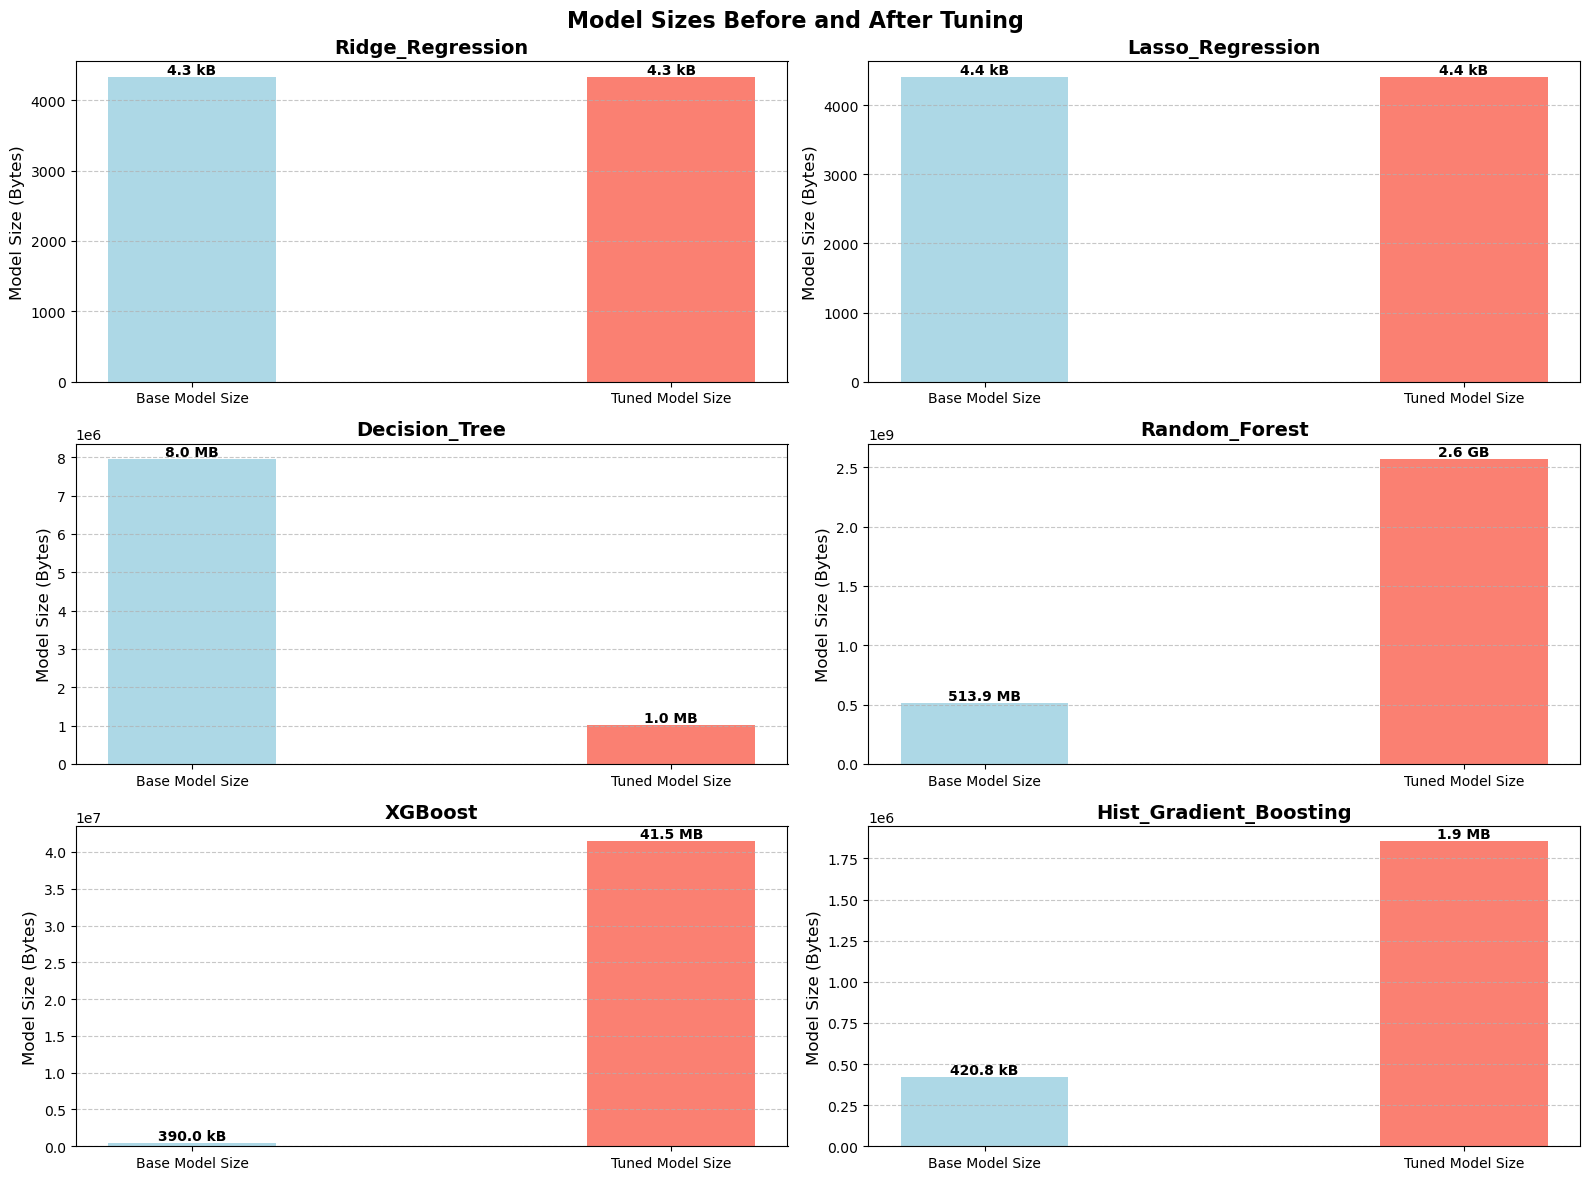

In [16]:
# Plotting individual subplots for each model
plt.figure(figsize=(16, 12))

# Loop to create individual subplots
for i, model_name in enumerate(model_names):
    plt.subplot(3, 2, i + 1)  # Adjust subplot layout (3 rows, 2 columns)
    
    # Bar widths and positions
    bar_width = 0.35
    x = [0, 1]  # Two bars for base and tuned model sizes

    # Create bars for base and tuned model sizes
    bars = plt.bar(x, [base_sizes[i], tuned_sizes[i]], width=bar_width, color=['lightblue', 'salmon'])
    
    # Add titles and labels
    plt.title(model_name, fontsize=14, fontweight='bold')
    plt.xticks(x, ['Base Model Size', 'Tuned Model Size'])
    plt.ylabel('Model Size (Bytes)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for better readability

    # Add labels on top of the bars using the human-readable sizes
    plt.text(0, base_sizes[i], base_sizes_h[i], ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.text(1, tuned_sizes[i], tuned_sizes_h[i], ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add a main title to all subplots
plt.suptitle(f"Model Sizes Before and After Tuning", fontsize=16, fontweight='bold')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display the plot
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler
import time

def generate_larger_dataset(test_data_path, desired_rows):
    # Load the test data
    test_data = pd.read_csv(test_data_path, encoding='utf-8')

    # Get the current number of rows
    current_rows = test_data.shape[0]

    # If the current number of rows is greater than or equal to the desired number, just return the subset
    if current_rows >= desired_rows:
        return test_data.head(desired_rows)
    
    # Calculate how many times we need to repeat the data to reach the desired number of rows
    multiplier = (desired_rows // current_rows) + 1

    # Repeat the data
    larger_data = pd.concat([test_data] * multiplier, ignore_index=True)

    # Shuffle the data and select only the desired number of rows
    larger_data = larger_data.sample(n=desired_rows, random_state=42).reset_index(drop=True)

    return larger_data

def predict_new_data(model_path, original_data_path, test_data_path, gen_test_rows = None):
    
    # Load the original data (used to align columns)
    df = pd.read_csv(original_data_path, encoding='utf-8')
    df = df.drop(columns=['price', 'square_feet'])

    # Columns to be treated as categorical
    cols = ["bathrooms", "bedrooms", "has_photo", "cityname", "state", "source"]
    df[cols] = df[cols].astype('category')

    # One-hot encode categorical variables
    data_encoded = pd.get_dummies(df, columns=cols, drop_first=True)

    # Define features
    X = data_encoded.drop(['log1p_price'], axis=1)

    # Load new data for prediction
    if gen_test_rows:
        new_data = generate_larger_dataset(test_data_path, gen_test_rows)
    else:
        new_data = pd.read_csv(test_data_path, encoding='utf-8')
    new_data = new_data.drop(columns=['price', 'square_feet'])
        
    # Columns to be treated as categorical
    new_data[cols] = new_data[cols].astype('category')

    # One-hot encode the new data
    new_data_encoded = pd.get_dummies(new_data, columns=cols, drop_first=True)

    # Ensure new data columns align with the training data columns
    new_data_encoded = new_data_encoded.reindex(columns=X.columns, fill_value=0)

    # Standardize the features using the same scaler that was used for training
    scaler = StandardScaler()
    new_data_scaled = scaler.fit_transform(new_data_encoded)

    # List of model names to load and predict
    model_names = ["Ridge Regression", "Lasso Regression", "Decision Tree", 
                   "Random Forest", "Hist Gradient Boosting", "XGBoost"]
    
    predictions = {}
    prediction_times = {}

    # Predict with each model and measure time taken
    for model_name in model_names:
        # Load the saved model
        model = joblib.load(f"{model_path}/model_{model_name.replace(' ', '_')}.pkl")

        # Start timing the prediction process
        start_time = time.time()

        # Make predictions in log scale
        y_pred_log = model.predict(new_data_scaled)

        # End timing the prediction process
        time_taken = time.time() - start_time

        # Back-transform predictions to the original scale
        y_pred_original = np.expm1(y_pred_log)  # Apply exp(y_pred) - 1

        predictions[model_name] = y_pred_original
        prediction_times[model_name] = time_taken

    # Store predictions in a DataFrame for comparison
    predictions_df = pd.DataFrame(predictions)

    return predictions_df, prediction_times

In [18]:
# Define paths
base_path = 'models/base'
tuned_path = 'models/tuned'

original_data_path = 'data_modified/engineered_data.csv'
test_data_path = 'src/modeling/test_data.csv'

# Predict 1_000_000 for both base and tuned models
base_predictions_df, base_prediction_times = predict_new_data(base_path, original_data_path, test_data_path, gen_test_rows=1000000)
tuned_predictions_df, tuned_prediction_times = predict_new_data(tuned_path, original_data_path, test_data_path, gen_test_rows=1000000)

In [19]:
# Combine base and tuned predictions for comparison
comparison_df = pd.DataFrame({
    'Base_Ridge': base_predictions_df['Ridge Regression'],
    'Tuned_Ridge': tuned_predictions_df['Ridge Regression'],
    'Base_Lasso': base_predictions_df['Lasso Regression'],
    'Tuned_Lasso': tuned_predictions_df['Lasso Regression'],
    'Base_DecisionTree': base_predictions_df['Decision Tree'],
    'Tuned_DecisionTree': tuned_predictions_df['Decision Tree'],
    'Base_RandomForest': base_predictions_df['Random Forest'],
    'Tuned_RandomForest': tuned_predictions_df['Random Forest'],
    'Base_HistGradientBoosting': base_predictions_df['Hist Gradient Boosting'],
    'Tuned_HistGradientBoosting': tuned_predictions_df['Hist Gradient Boosting'],
    'Base_XGBoost': base_predictions_df['XGBoost'],
    'Tuned_XGBoost': tuned_predictions_df['XGBoost']
})

# View combined predictions
print(comparison_df.head())

    Base_Ridge  Tuned_Ridge   Base_Lasso  Tuned_Lasso  Base_DecisionTree  \
0   771.450404   737.767329  1318.872734   956.368840             2670.0   
1   771.450404   737.767329  1318.872734   956.368840             2670.0   
2  1969.453569  2042.670593  1318.872734  1678.322434             1327.0   
3  1969.453569  2042.670593  1318.872734  1678.322434             1327.0   
4  1969.453569  2042.670593  1318.872734  1678.322434             1327.0   

   Tuned_DecisionTree  Base_RandomForest  Tuned_RandomForest  \
0         2559.417339        2326.759514         2281.071391   
1         2559.417339        2326.759514         2281.071391   
2         1202.782725        1181.701991         1136.403279   
3         1202.782725        1181.701991         1136.403279   
4         1202.782725        1181.701991         1136.403279   

   Base_HistGradientBoosting  Tuned_HistGradientBoosting  Base_XGBoost  \
0                1862.827737                 1581.862048   2181.386475   
1         

In [20]:
# Combine base and tuned prediction times for comparison
prediction_times_df = pd.DataFrame({
    'Model': base_prediction_times.keys(),
    'Base_Times': base_prediction_times.values(),
    'Tuned_Times': tuned_prediction_times.values()
})

# View prediction times
print("--Prediction times comparison (in seconds)--")
print(prediction_times_df)

--Prediction times comparison (in seconds)--
                    Model  Base_Times  Tuned_Times
0        Ridge Regression    0.730186     0.874005
1        Lasso Regression    0.683016     0.817174
2           Decision Tree    1.156792     1.305115
3           Random Forest    3.201311     5.569154
4  Hist Gradient Boosting    2.360582     7.537858
5                 XGBoost    1.255996     5.362675


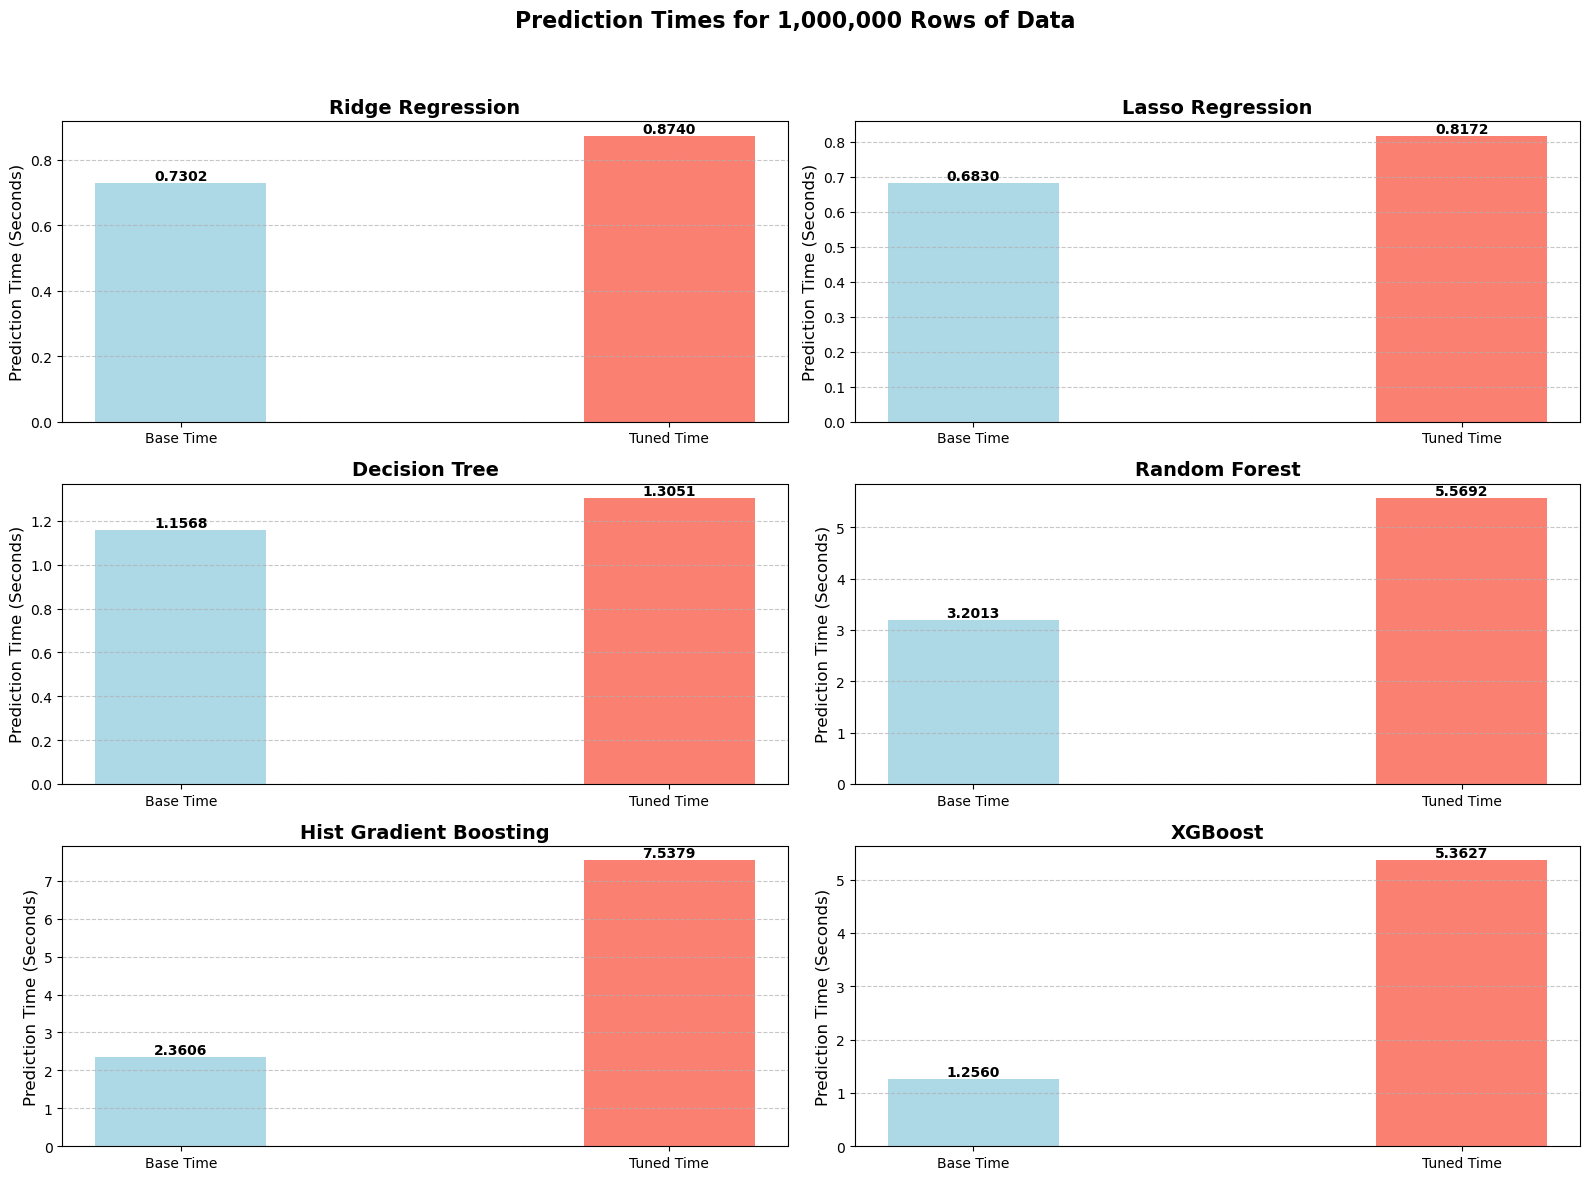

In [21]:
model_names = prediction_times_df['Model'].tolist()
base_times = prediction_times_df['Base_Times'].tolist()
tuned_times = prediction_times_df['Tuned_Times'].tolist()

# Get the number of rows in the comparison dataframe
num_rows = len(comparison_df)

# Plotting individual subplots for each model's prediction time
plt.figure(figsize=(16, 12))

# Loop to create individual subplots
for i, model_name in enumerate(model_names):
    plt.subplot(3, 2, i + 1)  # Adjust subplot layout (3 rows, 2 columns)
    
    # Bar widths and positions
    bar_width = 0.35
    x = [0, 1]  # Two bars for base and tuned model times

    # Create bars for base and tuned prediction times
    bars = plt.bar(x, [base_times[i], tuned_times[i]], width=bar_width, color=['lightblue', 'salmon'])
    
    # Add titles and labels
    plt.title(model_name, fontsize=14, fontweight='bold')
    plt.xticks(x, ['Base Time', 'Tuned Time'])
    plt.ylabel('Prediction Time (Seconds)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for better readability

    # Add labels on top of the bars
    plt.text(0, base_times[i], f'{base_times[i]:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.text(1, tuned_times[i], f'{tuned_times[i]:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add a main title to all subplots
plt.suptitle(f"Prediction Times for {num_rows:,} Rows of Data", fontsize=16, fontweight='bold')

# Adjust layout to prevent overlapping
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle

# Display the plot
plt.show()

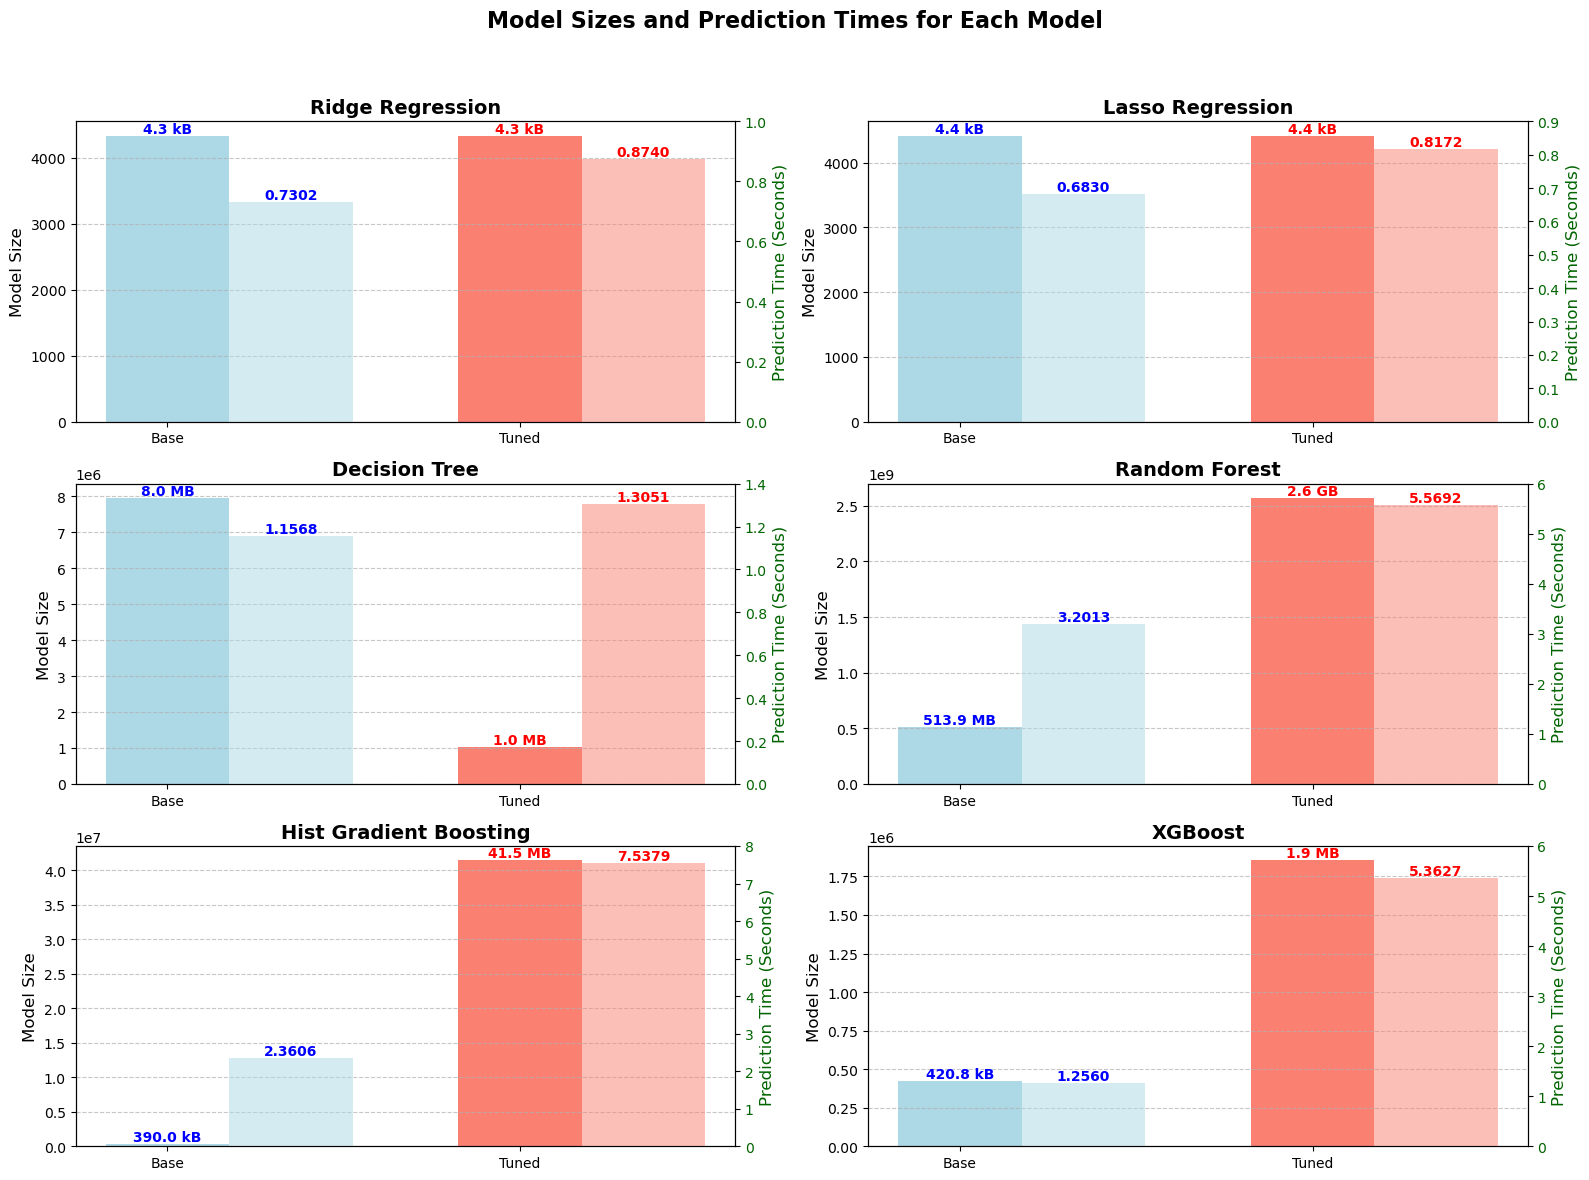

In [22]:
# Create a figure
plt.figure(figsize=(16, 12))

# Loop to create combined subplots for each model
for i, model_name in enumerate(model_names):
    ax1 = plt.subplot(3, 2, i + 1)  # Subplots in a 3x2 grid
    
    # Bar positions
    bar_width = 0.35
    x = [0, 1]  # Two bars for base and tuned
    
    # Plot model sizes on the primary y-axis
    bars1 = ax1.bar(x, [base_sizes[i], tuned_sizes[i]], width=bar_width, color=['lightblue', 'salmon'], label='Model Sizes')
    ax1.set_ylabel('Model Size', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(['Base', 'Tuned'])
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add size labels
    ax1.text(0, base_sizes[i], base_sizes_h[i], ha='center', va='bottom', fontsize=10, fontweight='bold', color='blue')
    ax1.text(1, tuned_sizes[i], tuned_sizes_h[i], ha='center', va='bottom', fontsize=10, fontweight='bold', color='red')

    # Create a secondary y-axis for prediction times
    ax2 = ax1.twinx()
    bars2 = ax2.bar([p + bar_width for p in x], [base_times[i], tuned_times[i]], width=bar_width, color=['lightblue', 'salmon'], alpha=0.5, label='Prediction Times')
    ax2.set_ylabel('Prediction Time (Seconds)', fontsize=12, color='darkgreen')
    
    # Add ticks and labels to the secondary axis (prediction times)
    ax2.set_yticks(ax2.get_yticks())  # Make sure ax2 has ticks
    ax2.yaxis.set_tick_params(labelcolor='darkgreen')
    
    # Add time labels with the same colors for base and tuned as model size
    ax2.text(0 + bar_width, base_times[i], f'{base_times[i]:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='blue')
    ax2.text(1 + bar_width, tuned_times[i], f'{tuned_times[i]:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='red')
    
    # Add title for each model
    plt.title(model_name, fontsize=14, fontweight='bold')

# Add a main title to the entire figure
plt.suptitle("Model Sizes and Prediction Times for Each Model", fontsize=16, fontweight='bold')

# Adjust layout to prevent overlapping
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Display the plot
plt.show()
